# Exercício 1 da disciplina Fundamentos de Sistemas Inteligentes

### Aluno 1: Artur Mateo Freire de Jesus 14745525
### Aluno 2: Vinicius Galioti Barbosa 14611133
### Professor: Magno Teófilo Madeira da Silva

In [1088]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [1089]:
air_data = pd.read_csv(
    "../air_quality.csv",
    sep=",",
    decimal=".",
    na_values=["", " ", "NA", -200]
)
print("Colunas originais:", air_data.columns.tolist())

Colunas originais: ['Date', 'Time', 'CO', 'Poluente_1', 'Poluente_2', 'Poluente_3', 'Poluente_4', 'Poluente_5', 'Poluente_6', 'Poluente_7', 'Poluente_8', 'Poluente_9', 'T', 'RH', 'AH']


In [1090]:
air_data.head()

,Date,Time,CO,Poluente_1,Poluente_2,Poluente_3,Poluente_4,Poluente_5,Poluente_6,Poluente_7,Poluente_8,Poluente_9,T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


 A descrição dos dados é a seguinte:


| Coluna        | Descrição |
|---------------|------------|
| `Date`        | Data da medição no formato dia/mês/ano. |
| `Time`        | Horário da medição no formato hora:minuto:segundo. |
| `CO`          | Concentração de monóxido de carbono (variável alvo do modelo). |
| `Poluente_n`  | Medição de poluente atmosférico. |
| `T`           | Temperatura ambiente (°C). |
| `RH`          | Umidade relativa do ar (%). |
| `AH`          | Umidade absoluta do ar. |            |

In [1091]:
missing_pecentage = air_data.isna().mean() * 100

print("Porcentagem de valores faltando em cada coluna")
print(f'{missing_pecentage.round(6)}')

Porcentagem de valores faltando em cada coluna
Date           1.203674
Time           1.203674
CO            18.973709
Poluente_1     5.068103
Poluente_2    90.349488
Poluente_3     5.068103
Poluente_4     5.068103
Poluente_5    18.509133
Poluente_6     5.068103
Poluente_7    18.540809
Poluente_8     5.068103
Poluente_9     5.068103
T              5.068103
RH             5.068103
AH             5.068103
dtype: float64


### Remoção de colunas

In [1092]:
air_data = air_data.drop(columns=["Poluente_2"])

In [1093]:
air_data = air_data.dropna(subset=["Date", "Time"])
air_data["DateTime"] = pd.to_datetime(
    air_data["Date"] + " " + air_data["Time"],
    format="%d/%m/%Y %H.%M.%S",
    )
air_data = air_data.dropna(subset=["DateTime"])

In [1094]:
air_data = air_data.set_index("DateTime")
air_data = air_data.drop(columns=["Date", "Time"])

In [1095]:
air_data["Hora"] = air_data.index.hour
air_data["Dia"] = air_data.index.day
air_data["Mes"] = air_data.index.month

### Correlação entre dados

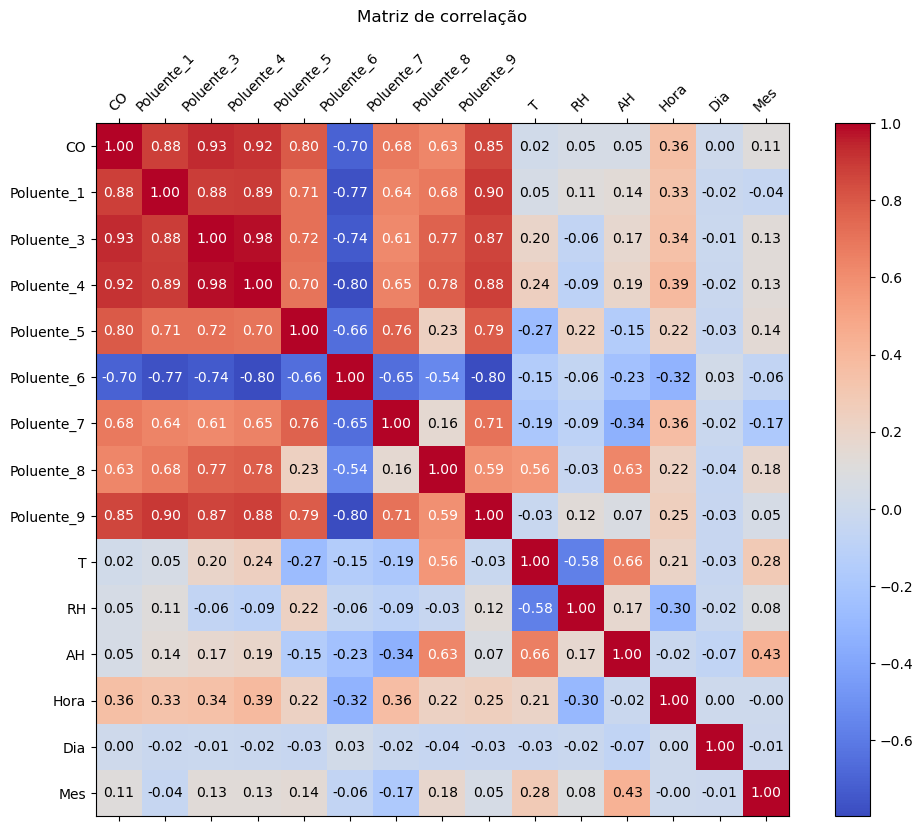

In [1096]:
corr_matrix = air_data.corr()

fig, ax = plt.subplots(figsize=(12, 9))
cax = ax.matshow(corr_matrix, cmap='coolwarm')

fig.colorbar(cax)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        text_color = "white" if abs(value) > 0.5 else "black"
        
        ax.text(j, i, f"{value:.2f}", 
                ha="center", va="center", color=text_color, fontsize=10)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

plt.title("Matriz de correlação", pad=20)
plt.show()

### Adição de novas variáveis

In [1097]:
# Exemplos do enunciado
air_data["CO_media_movel_3h"] = air_data["CO"].shift(1).rolling(window=3, min_periods=1).mean()
air_data["CO_std_movel_3h"] = air_data["CO"].rolling(window=3, min_periods=1).std()
air_data["Razao_P5_P7"] = air_data["Poluente_5"] / air_data["Poluente_7"]
air_data["Temp_x_UmidadeRelativa"] = air_data["T"] * air_data["RH"] # Produto de variáveis com baixa correlação com CO 

# Criando razões entre sensores com alta correlação entre sí
air_data["Razao_P1_P9"] = air_data["Poluente_1"] / air_data["Poluente_9"]
air_data["Razao_P3_P4"] = air_data["Poluente_3"] / air_data["Poluente_4"]

air_data = air_data.drop(columns=[
                                    "Poluente_1", 
                                    "Poluente_4",
                                    "Poluente_5",
                                  ])

air_data["CO_lag1"] = air_data["CO"].shift(1)



air_data = air_data.dropna()


print(len(air_data))

6767


### Separação e normalização dos dados

In [1098]:
x_data = air_data.drop(columns=['CO'])
y_data = air_data['CO']

x_data = (x_data - x_data.mean()) / x_data.std()

tamanho_treino = int(0.7 * len(air_data))
x_treino, x_teste = x_data.iloc[:tamanho_treino], x_data.iloc[tamanho_treino:]
y_treino, y_teste = y_data.iloc[:tamanho_treino], y_data.iloc[tamanho_treino:]

### Solução de Weiner

In [1099]:
# Returns the wiener solution for the problem
def wiener_sol(x, d, Nt):
    M = x.shape[1]
    x = np.hstack((np.ones((Nt, 1)), x))

    R = np.zeros((M + 1, M + 1))
    p = np.zeros((M + 1, 1))

    accum_R = np.zeros((M + 1, M + 1))
    accum_p = np.zeros((M + 1, 1))

    for i in range(Nt):
        x_n = x[i, :].reshape(-1, 1)
        
        sum_term = np.matmul(x_n, x_n.T)
        accum_R = np.add(accum_R, sum_term)

        sum_term = np.multiply(x_n, d[i])
        accum_p = np.add(accum_p, sum_term)
    
    R = np.divide(accum_R, Nt)
    p = np.divide(accum_p, Nt)

    W_Wiener = np.linalg.solve(R, p) 

    return W_Wiener

In [1100]:
x_data = air_data.drop(columns=['CO'])
Ww = wiener_sol(x_treino.to_numpy(), y_treino.to_numpy(), tamanho_treino)

# Cálculo do erro

In [1101]:
def mse(d, x, w):

    N = x.shape[0]
    xd = np.hstack((np.ones((N, 1)), x))
    e = d.reshape(-1, 1) - np.matmul(xd, w.reshape(-1, 1))
    mse_val = np.mean(e**2)

    return mse_val 

In [1102]:
print(f'Wiener model error in training set: {mse(y_treino.to_numpy(), x_treino.to_numpy(), Ww)}')

print(f'Wiener model error in validation set: {mse(y_teste.to_numpy(), x_teste.to_numpy(), Ww)}')
print(f'CO mean value: {np.mean(air_data['CO'])}')


Wiener model error in training set: 0.10298064645703085
Wiener model error in validation set: 0.37297804657059536
CO mean value: 2.2120289640904387


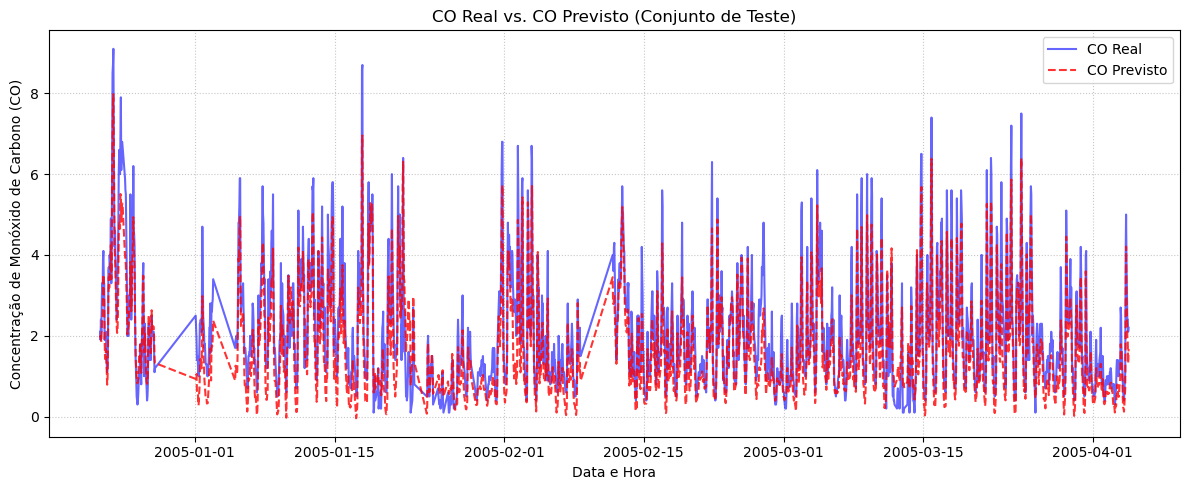

In [1103]:
plt.figure(figsize=(12, 5))

plt.plot(y_teste.index, y_teste.values, label="CO Real", color='blue', alpha=0.6)

N = x_teste.shape[0]
xd = np.hstack((np.ones((N, 1)), x_teste))
plt.plot(y_teste.index, np.matmul(xd, Ww), label="CO Previsto", color='red', alpha=0.8, linestyle='--')

plt.title("CO Real vs. CO Previsto (Conjunto de Teste)")
plt.xlabel("Data e Hora")
plt.ylabel("Concentração de Monóxido de Carbono (CO)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()